In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/monthly_milk_production.csv")

# Display first 5 rows
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (168, 2)

Column Names:
['Date', 'Production']

Data Types:
Date            str
Production    int64
dtype: object

Missing Values:
Date          0
Production    0
dtype: int64


In [4]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as the index
df.set_index('Date', inplace=True)

# Display first 5 rows
print(df.head())

# Display last 5 rows
print("\nLast 5 rows:")
print(df.tail())

# Display statistical summary
print("\nStatistical Summary:")
print(df['Production'].describe())

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727

Last 5 rows:
            Production
Date                  
1975-08-01         858
1975-09-01         817
1975-10-01         827
1975-11-01         797
1975-12-01         843

Statistical Summary:
count    168.000000
mean     754.708333
std      102.204524
min      553.000000
25%      677.750000
50%      761.000000
75%      824.500000
max      969.000000
Name: Production, dtype: float64


In [5]:
# Check date range
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

# Check for duplicate dates
print("Duplicate Dates:", df.index.duplicated().sum())

Start Date: 1962-01-01 00:00:00
End Date: 1975-12-01 00:00:00
Duplicate Dates: 0


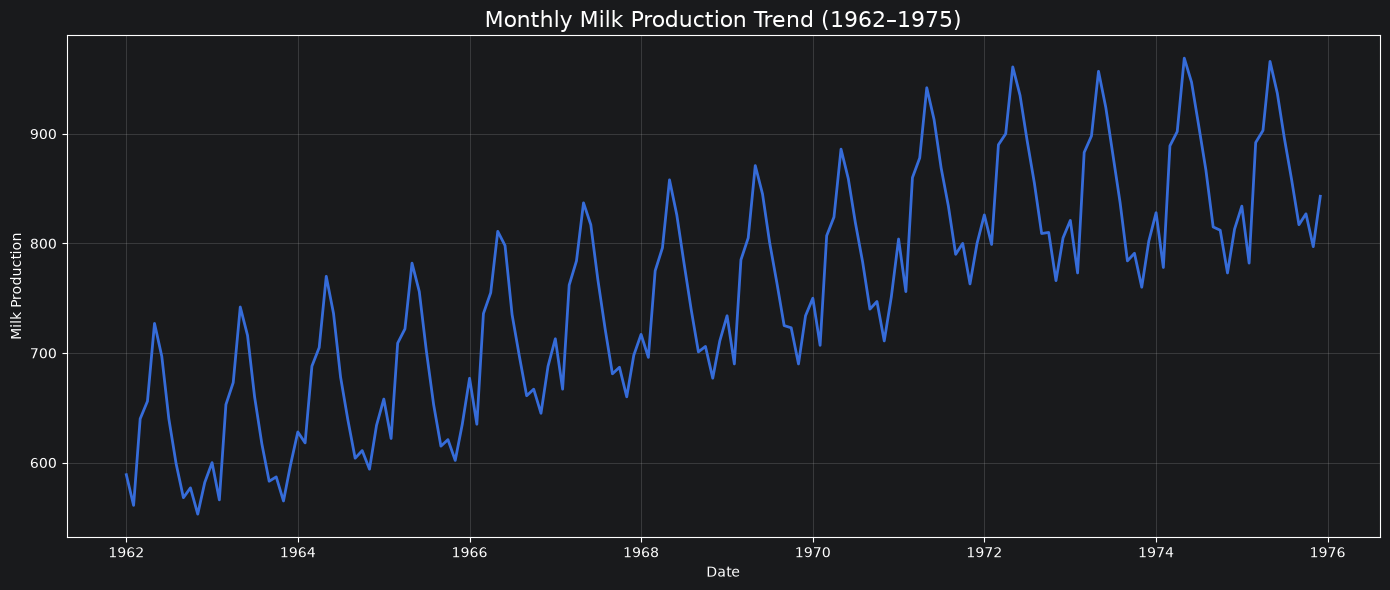

In [6]:
# Plot monthly milk production trend

plt.figure(figsize=(14, 6))

plt.plot(
    df.index,
    df['Production'],
    linewidth=2
)

plt.title('Monthly Milk Production Trend (1962–1975)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Create a month column for seasonal analysis
df['Month'] = df.index.month

# Calculate average production for each month
monthly_avg = df.groupby('Month')['Production'].mean()

print("Average Production by Month:")
print(monthly_avg)

Average Production by Month:
Month
1     727.071429
2     689.285714
3     783.500000
4     800.071429
5     862.785714
6     836.142857
7     788.071429
8     747.500000
9     706.642857
10    711.857143
11    682.571429
12    721.000000
Name: Production, dtype: float64


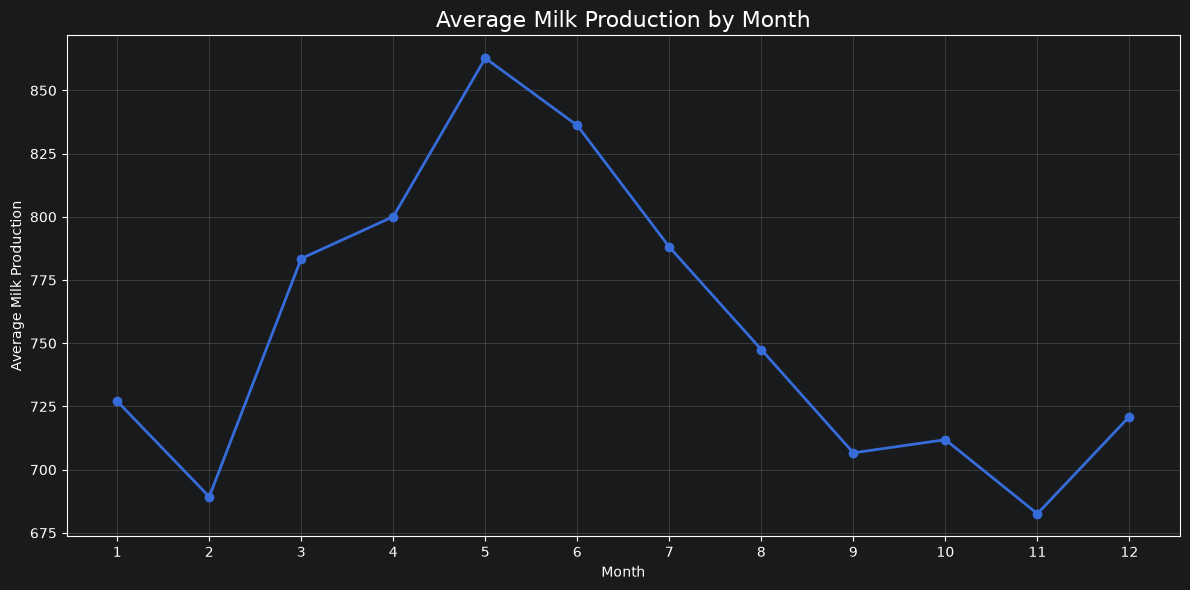

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',
    linewidth=2
)

plt.title('Average Milk Production by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Milk Production')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Check for outliers using the IQR method

Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Production'] < lower_bound) |
    (df['Production'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Outliers:", len(outliers))

print("\nOutlier Values:")
print(outliers)

Q1: 677.75
Q3: 824.5
IQR: 146.75
Lower Bound: 457.625
Upper Bound: 1044.625

Number of Outliers: 0

Outlier Values:
Empty DataFrame
Columns: [Production, Month]
Index: []


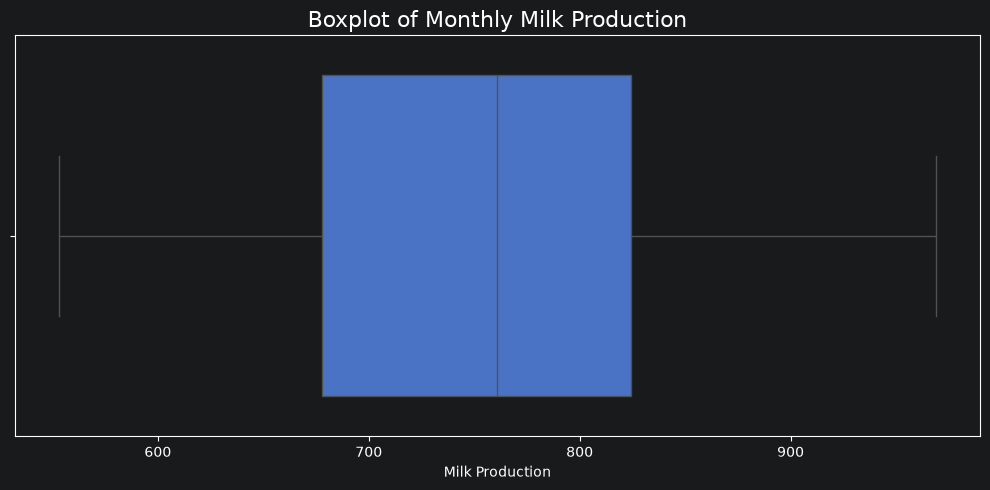

In [10]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Production'])

plt.title('Boxplot of Monthly Milk Production', fontsize=16)
plt.xlabel('Milk Production')

plt.tight_layout()
plt.show()

In [11]:
# Remove temporary Month column
df = df.drop(columns=['Month'])

# Select production values
data = df[['Production']].values

print("Data shape:", data.shape)
print("First 5 values:")
print(data[:5])

Data shape: (168, 1)
First 5 values:
[[589]
 [561]
 [640]
 [656]
 [727]]


In [13]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale production data
scaled_data = scaler.fit_transform(data)

print("Scaled data shape:", scaled_data.shape)
print("\nFirst 5 scaled values:")
print(scaled_data[:5])

Scaled data shape: (168, 1)

First 5 scaled values:
[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [14]:
# Define the time window
window_size = 12

# Create sequences
X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12)
y shape: (156,)


In [15]:
# Calculate split sizes
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

# Split chronologically
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

# Display shapes
print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation set:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (109, 12)
y_train: (109,)

Validation set:
X_val: (23, 12)
y_val: (23,)

Test set:
X_test: (24, 12)
y_test: (24,)


In [16]:
# Reshape input data for RNN, LSTM, and GRU
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Check the new shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (109, 12, 1)
X_val shape: (23, 12, 1)
X_test shape: (24, 12, 1)


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense

# Build Basic RNN model
rnn_model = Sequential([
    Input(shape=(12, 1)),
    SimpleRNN(64, activation='tanh'),
    Dense(1)
])

# Compile the model
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

# Display model summary
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train Basic RNN
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0801 - val_loss: 0.0111
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0170 - val_loss: 0.0575
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0034
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0078
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 - val_loss: 0.0110
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - val_loss: 0.0034
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0046
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0053
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - val_loss: 0.0043
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0027
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - val_loss: 0.0031


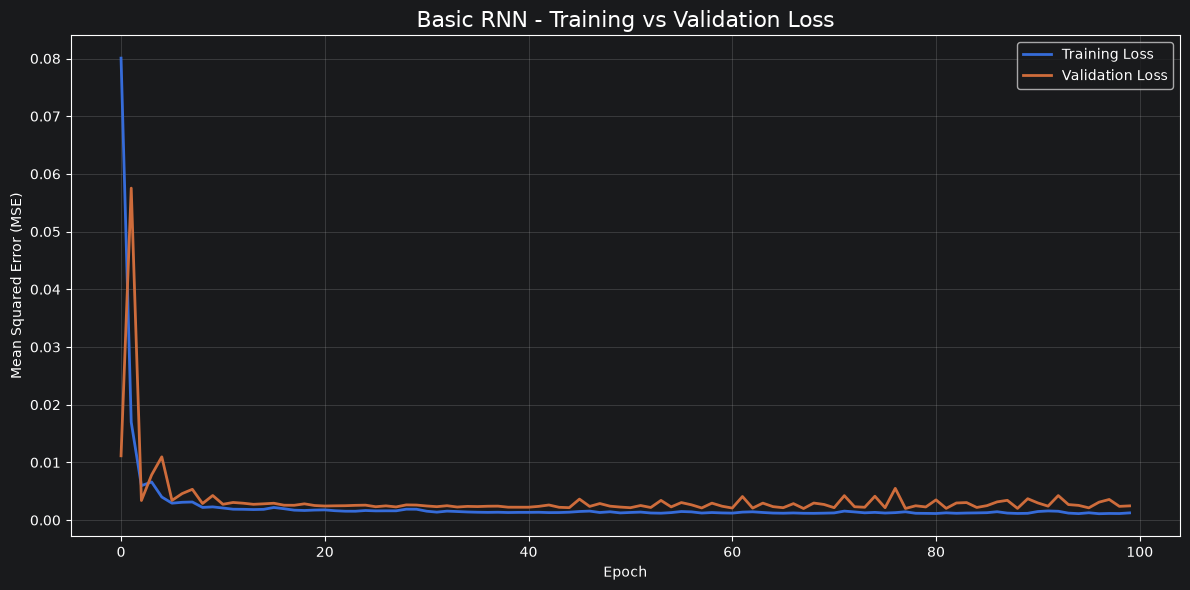

In [22]:
# Plot training and validation loss

plt.figure(figsize=(12, 6))

plt.plot(
    rnn_history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    rnn_history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title('Basic RNN - Training vs Validation Loss', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Generate predictions on the test set
rnn_pred_scaled = rnn_model.predict(X_test)

print("Prediction shape:", rnn_pred_scaled.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Prediction shape: (24, 1)


In [24]:
# Convert predictions back to original scale
rnn_pred = scaler.inverse_transform(rnn_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("First 5 actual values:")
print(y_test_actual[:5].flatten())

print("\nFirst 5 predicted values:")
print(rnn_pred[:5].flatten())

First 5 actual values:
[828. 778. 889. 902. 969.]

First 5 predicted values:
[833.5509  805.21454 882.45514 901.6092  956.04364]


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate RMSE
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_pred))

# Calculate MAE
rnn_mae = mean_absolute_error(y_test_actual, rnn_pred)

# Calculate MAPE
rnn_mape = np.mean(
    np.abs((y_test_actual - rnn_pred) / y_test_actual)
) * 100

print("Basic RNN Test Performance")
print("--------------------------------")
print(f"RMSE : {rnn_rmse:.4f}")
print(f"MAE  : {rnn_mae:.4f}")
print(f"MAPE : {rnn_mape:.2f}%")

Basic RNN Test Performance
--------------------------------
RMSE : 12.6494
MAE  : 9.9667
MAPE : 1.18%


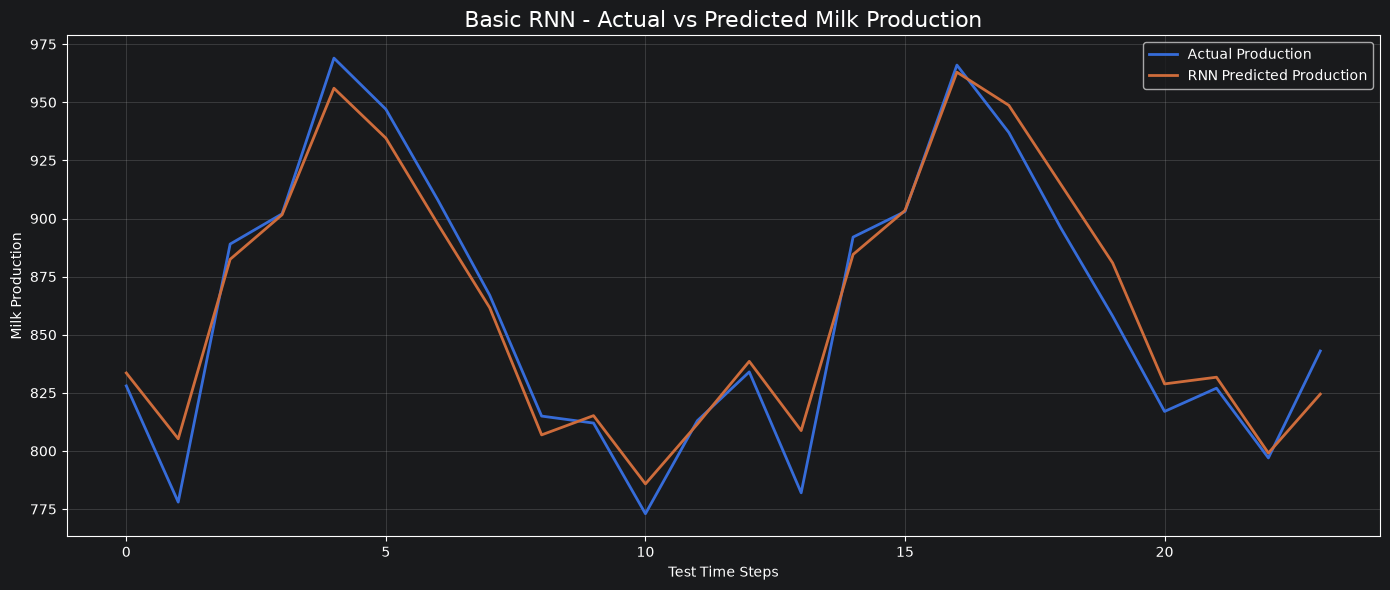

In [26]:
# Plot Actual vs Predicted values for Basic RNN

plt.figure(figsize=(14, 6))

plt.plot(
    y_test_actual.flatten(),
    label='Actual Production',
    linewidth=2
)

plt.plot(
    rnn_pred.flatten(),
    label='RNN Predicted Production',
    linewidth=2
)

plt.title('Basic RNN - Actual vs Predicted Milk Production', fontsize=16)
plt.xlabel('Test Time Steps')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
from tensorflow.keras.layers import LSTM

# Build LSTM model
lstm_model = Sequential([
    Input(shape=(12, 1)),
    LSTM(64, activation='tanh'),
    Dense(1)
])

# Compile the model
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

# Display model architecture
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train LSTM
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1666 - val_loss: 0.2153
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0597 - val_loss: 0.0294
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0304 - val_loss: 0.0347
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0284 - val_loss: 0.0316
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0263 - val_loss: 0.0397
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0264 - val_loss: 0.0321
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0254 - val_loss: 0.0267
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0251 - val_loss: 0.0272
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0246 - val_loss: 0.0303
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0244 - val_loss: 0.0266
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0238 - val_loss: 0.0267
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0241 - val_loss: 0.0252


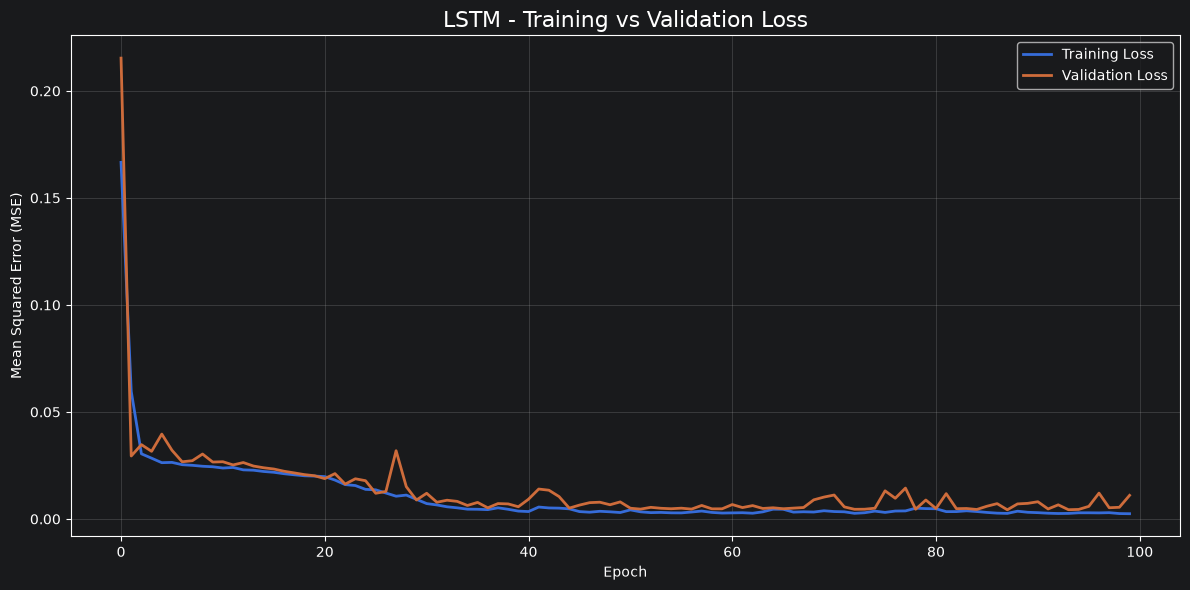

In [29]:
# Plot LSTM training and validation loss

plt.figure(figsize=(12, 6))

plt.plot(
    lstm_history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    lstm_history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title('LSTM - Training vs Validation Loss', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Generate LSTM predictions
lstm_pred_scaled = lstm_model.predict(X_test)

print("Prediction shape:", lstm_pred_scaled.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Prediction shape: (24, 1)


In [31]:
# Convert LSTM predictions back to original scale
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

print("First 5 actual values:")
print(y_test_actual[:5].flatten())

print("\nFirst 5 LSTM predicted values:")
print(lstm_pred[:5].flatten())

First 5 actual values:
[828. 778. 889. 902. 969.]

First 5 LSTM predicted values:
[832.27356 855.6847  888.5718  928.15814 953.35803]


In [32]:
# Calculate LSTM performance metrics

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)

lstm_mape = np.mean(
    np.abs((y_test_actual - lstm_pred) / y_test_actual)
) * 100

print("LSTM Test Performance")
print("--------------------------------")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"MAE  : {lstm_mae:.4f}")
print(f"MAPE : {lstm_mape:.2f}%")

LSTM Test Performance
--------------------------------
RMSE : 38.1469
MAE  : 30.4502
MAPE : 3.64%


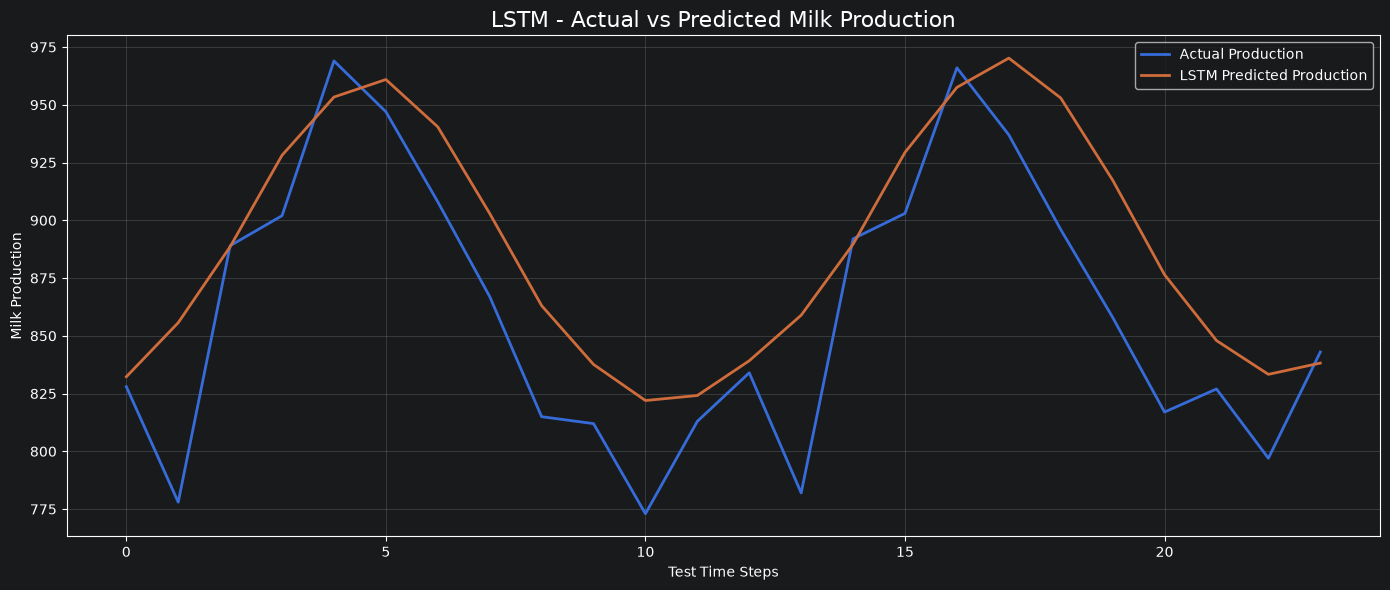

In [33]:
# Plot Actual vs Predicted values for LSTM

plt.figure(figsize=(14, 6))

plt.plot(
    y_test_actual.flatten(),
    label='Actual Production',
    linewidth=2
)

plt.plot(
    lstm_pred.flatten(),
    label='LSTM Predicted Production',
    linewidth=2
)

plt.title('LSTM - Actual vs Predicted Milk Production', fontsize=16)
plt.xlabel('Test Time Steps')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
from tensorflow.keras.layers import GRU

# Build GRU model
gru_model = Sequential([
    Input(shape=(12, 1)),
    GRU(64, activation='tanh'),
    Dense(1)
])

# Compile the model
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

# Display model architecture
gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train GRU
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2100 - val_loss: 0.3281
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0758 - val_loss: 0.0903
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0297 - val_loss: 0.0264
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0386 - val_loss: 0.0273
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0283 - val_loss: 0.0502
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0276 - val_loss: 0.0605
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0269 - val_loss: 0.0503
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0250 - val_loss: 0.0364
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0245 - val_loss: 0.0313
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0236 - val_loss: 0.0365
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0227 - val_loss: 0.0360
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0221 - val_loss: 0.0345


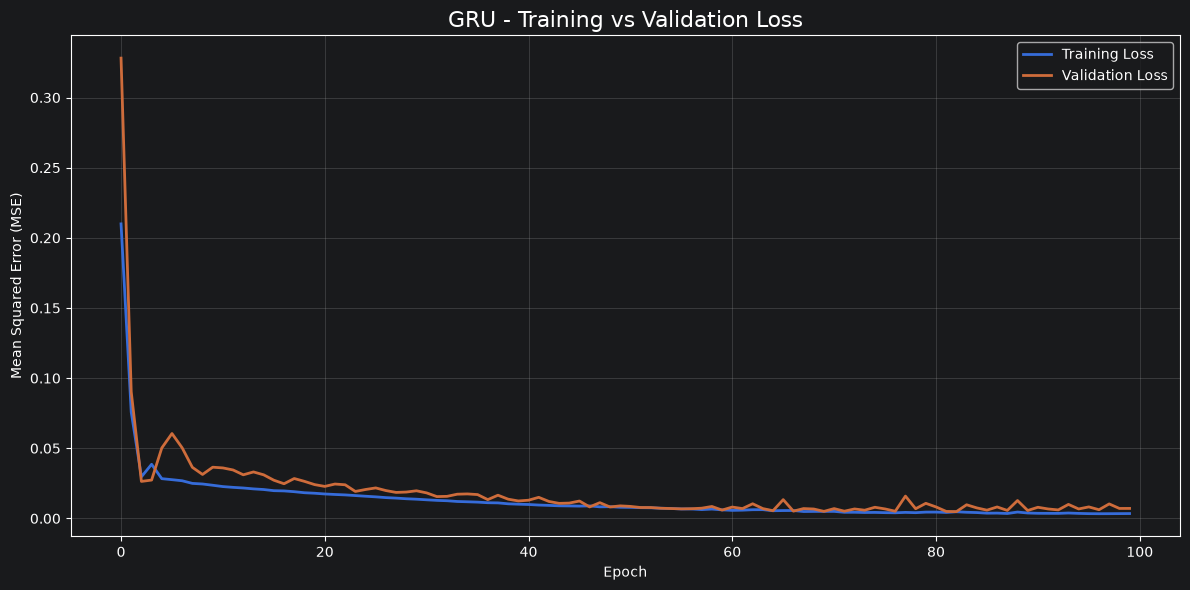

In [36]:
# Plot GRU training and validation loss

plt.figure(figsize=(12, 6))

plt.plot(
    gru_history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    gru_history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title('GRU - Training vs Validation Loss', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Generate GRU predictions
gru_pred_scaled = gru_model.predict(X_test)

print("Prediction shape:", gru_pred_scaled.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Prediction shape: (24, 1)


In [38]:
# Convert GRU predictions back to original scale
gru_pred = scaler.inverse_transform(gru_pred_scaled)

print("First 5 actual values:")
print(y_test_actual[:5].flatten())

print("\nFirst 5 GRU predicted values:")
print(gru_pred[:5].flatten())

First 5 actual values:
[828. 778. 889. 902. 969.]

First 5 GRU predicted values:
[805.24176 831.25806 847.4156  890.66327 938.78534]


In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Flatten actual and predicted values
y_true = y_test_actual.flatten()
y_pred = gru_pred.flatten()

# Calculate metrics
gru_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
gru_mae = mean_absolute_error(y_true, y_pred)
gru_mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("GRU Test Performance")
print("--------------------------------")
print(f"RMSE : {gru_rmse:.4f}")
print(f"MAE  : {gru_mae:.4f}")
print(f"MAPE : {gru_mape:.2f}%")

GRU Test Performance
--------------------------------
RMSE : 33.2597
MAE  : 29.2374
MAPE : 3.42%


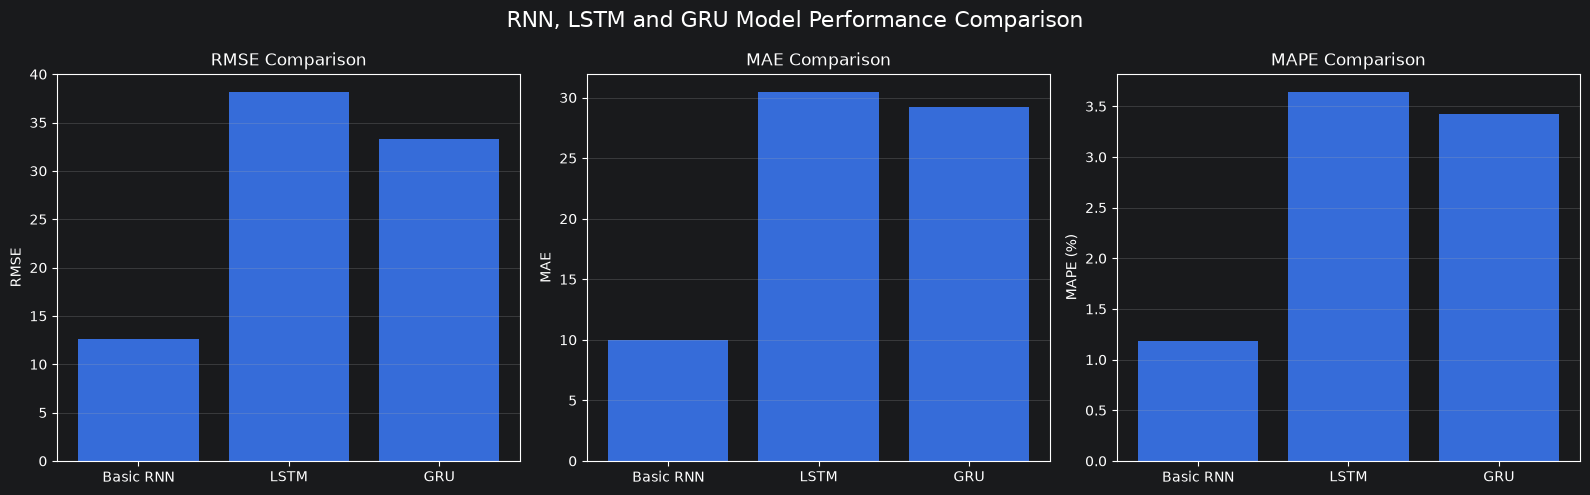

In [40]:
# Model performance comparison

models = ['Basic RNN', 'LSTM', 'GRU']

rmse_values = [12.6494, 38.1469, 33.2597]
mae_values = [9.9667, 30.4502, 29.2374]
mape_values = [1.18, 3.64, 3.42]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE
axes[0].bar(models, rmse_values)
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE')
axes[0].grid(axis='y', alpha=0.3)

# MAE
axes[1].bar(models, mae_values)
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE')
axes[1].grid(axis='y', alpha=0.3)

# MAPE
axes[2].bar(models, mape_values)
axes[2].set_title('MAPE Comparison')
axes[2].set_ylabel('MAPE (%)')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle(
    'RNN, LSTM and GRU Model Performance Comparison',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [41]:
# Create final comparison table

comparison_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'MAE': mae_values,
    'MAPE (%)': mape_values
})

comparison_df

,Model,RMSE,MAE,MAPE (%)
0,Basic RNN,12.6494,9.9667,1.18
1,LSTM,38.1469,30.4502,3.64
2,GRU,33.2597,29.2374,3.42


Conclusion: Three recurrent neural network architectures, namely Basic RNN, LSTM, and GRU, were developed and evaluated for monthly milk production forecasting. The Basic RNN achieved the best performance with an RMSE of 12.6494, MAE of 9.9667, and MAPE of 1.18%. GRU achieved the second-best performance, while LSTM produced the highest prediction errors. Based on the test-set evaluation, the Basic RNN is the most suitable model among the three for this dataset.